In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display

# Import AI Tools từ Scikit-Learn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

sns.set_theme(style="whitegrid")

df_modeling = pd.read_csv('../data/processed/retail_customers.csv', index_col=0)
print(f"Data shape: {df_modeling.shape}")
print("Ready for K-Means!")

Data shape: (3742, 15)
Ready for K-Means!


In [154]:
# ============================================================
# Candidate configuration
# ============================================================

# K values retained after the initial K-selection sweep.
# We only compare these two candidates from this point onward.
CANDIDATE_K = [4, 5]

# Fixed seed for the final reproducible model
BASE_SEED = 42

# Number of random seeds used for stability analysis
STABILITY_SEEDS = range(20)

# Get all modelling features.
feature_cols = df_modeling.columns.tolist()

# Keep the modelling matrix explicitly separate from identifiers.
X = df_modeling[feature_cols].copy()

# Basic validation before running further analysis
assert X.select_dtypes(include=np.number).shape[1] == len(feature_cols), \
    "All modelling features must be numeric."

assert X.isna().sum().sum() == 0, \
    "Missing values exist in the modelling dataset."

print(f"Number of customers: {len(X):,}")
print(f"Number of modelling features: {len(feature_cols)}")
print(f"Candidate K values: {CANDIDATE_K}")

Number of customers: 3,742
Number of modelling features: 15
Candidate K values: [4, 5]


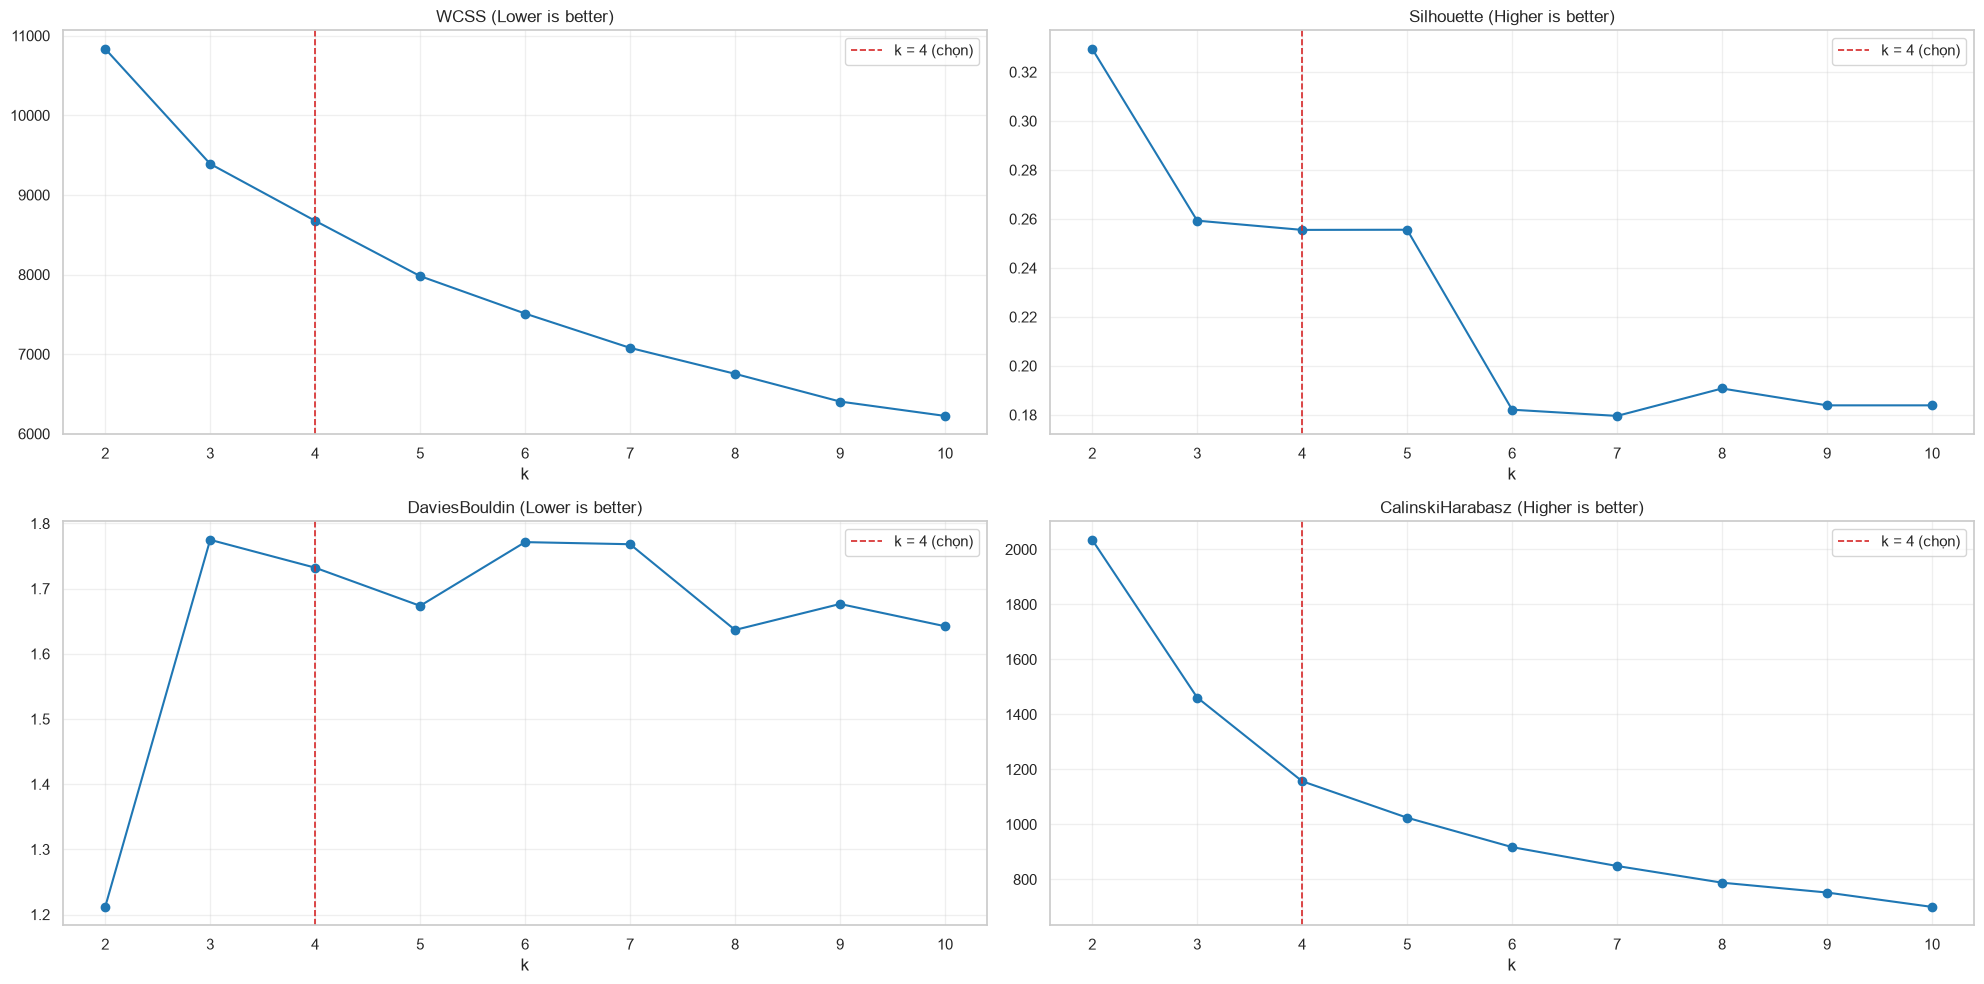

          WCSS  Silhouette  DaviesBouldin  CalinskiHarabasz
k                                                          
2   10835.2185      0.3295         1.2117         2034.8867
3    9390.1360      0.2593         1.7749         1461.4118
4    8675.1242      0.2555         1.7321         1156.9895
5    7980.5923      0.2556         1.6736         1024.3129
6    7510.0833      0.1821         1.7714          917.3684
7    7079.0449      0.1796         1.7682          848.7176
8    6753.2939      0.1908         1.6366          788.0814
9    6405.0249      0.1839         1.6765          752.2458
10   6224.4533      0.1839         1.6423          699.9036


In [155]:
rows = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lab = model.fit_predict(df_modeling) 
    
    rows.append({
        'k': k,
        'WCSS': model.inertia_, 
        'Silhouette': silhouette_score(df_modeling, lab),
        'DaviesBouldin': davies_bouldin_score(df_modeling, lab),
        'CalinskiHarabasz': calinski_harabasz_score(df_modeling, lab)
    })
    
metrics = pd.DataFrame(rows).set_index('k')


fig, ax = plt.subplots(2, 2, figsize=(20, 10)) 
ax = ax.flatten() 

metrics_cols = ['WCSS', 'Silhouette', 'DaviesBouldin', 'CalinskiHarabasz']
titles = ['Lower is better', 'Higher is better', 'Lower is better', 'Higher is better']

for a, col, tot in zip(ax, metrics_cols, titles):
    a.plot(metrics.index, metrics[col], marker='o', color='#1f77b4') 
    a.axvline(4, color='#d62728', ls='--', lw=1.2, label='k = 4 (chọn)') 
    a.set_title(f'{col} ({tot})')
    a.set_xlabel('k')
    a.grid(alpha=0.3)
    a.legend()

plt.tight_layout()
plt.show()

print(metrics.round(4).to_string())

### Obserrvation
- According to Silhouette Score, DaviesBouldin Score and CalinskiHarabasz Score, the most optimal value for K is 2. From a business perspective, segmenting the customer base into just two broad groups is too simplistic and not efficient for targeted marketing.
- WCSS decreases sharply from K=2 to K=4, while the marginal improvement becomes progressively smaller after K=4. Therefore, K=4 or K =5 represents reasonable elbows point that balances model complexity and within-cluster compactness.

### Action: 
* We continue analyse whether K=4 or K=5 should be the value for K using: 
    * Stability analysis across multiple random seeds
    * Adjusted Rand Index
    * Cluster size 
    * behaviour profile 
    * PCA.



In [156]:
# Stability analysis across multiple random seeds

stability_rows = []

for k in CANDIDATE_K:
    print(f"Running stability analysis for K={k}...")

    for seed in STABILITY_SEEDS:
        # Fit K-Means with a different random seed
        model = KMeans(
            n_clusters=k,
            init='k-means++',
            n_init=20,
            max_iter=300,
            random_state=seed
        )

        labels = model.fit_predict(X)

        # Calculate clustering quality metrics
        silhouette = silhouette_score(X, labels)
        dbi = davies_bouldin_score(X, labels)
        ch = calinski_harabasz_score(X, labels)

        stability_rows.append({
            'K': k,
            'Seed': seed,
            'WCSS': model.inertia_,
            'Silhouette': silhouette,
            'DaviesBouldin': dbi,
            'CalinskiHarabasz': ch
        })

stability_results = pd.DataFrame(stability_rows)

# Aggregate the results across seeds
stability_summary = (
    stability_results
    .groupby('K')
    .agg(
        WCSS_Mean=('WCSS', 'mean'),
        WCSS_Std=('WCSS', 'std'),

        Silhouette_Mean=('Silhouette', 'mean'),
        Silhouette_Std=('Silhouette', 'std'),

        DaviesBouldin_Mean=('DaviesBouldin', 'mean'),
        DaviesBouldin_Std=('DaviesBouldin', 'std'),

        CalinskiHarabasz_Mean=('CalinskiHarabasz', 'mean'),
        CalinskiHarabasz_Std=('CalinskiHarabasz', 'std')
    )
)

print("\nStability summary:")
print(stability_summary.round(5).to_string())

Running stability analysis for K=4...
Running stability analysis for K=5...

Stability summary:
    WCSS_Mean  WCSS_Std  Silhouette_Mean  Silhouette_Std  DaviesBouldin_Mean  DaviesBouldin_Std  CalinskiHarabasz_Mean  CalinskiHarabasz_Std
K                                                                                                                                           
4  8675.15456   0.01275          0.25561         0.00004             1.73181            0.00016             1156.98188               0.00362
5  7984.18743  15.86555          0.25559         0.00017             1.67268            0.00406             1023.45054               3.86014


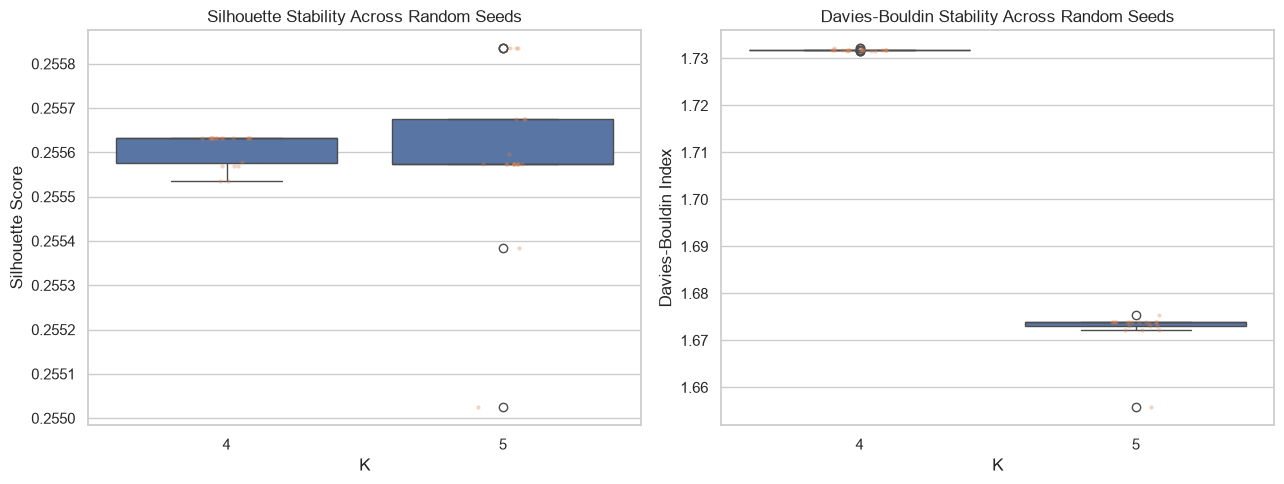

In [157]:
# Visualise stability across random seeds

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5)
)

# Silhouette distribution

sns.boxplot(
    data=stability_results,
    x='K',
    y='Silhouette',
    ax=axes[0]
)

sns.stripplot(
    data=stability_results,
    x='K',
    y='Silhouette',
    ax=axes[0],
    alpha=0.35,
    size=3
)

axes[0].set_title(
    'Silhouette Stability Across Random Seeds'
)

axes[0].set_xlabel('K')
axes[0].set_ylabel('Silhouette Score')

# Davies-Bouldin distribution

sns.boxplot(
    data=stability_results,
    x='K',
    y='DaviesBouldin',
    ax=axes[1]
)

sns.stripplot(
    data=stability_results,
    x='K',
    y='DaviesBouldin',
    ax=axes[1],
    alpha=0.35,
    size=3
)

axes[1].set_title(
    'Davies-Bouldin Stability Across Random Seeds'
)

axes[1].set_xlabel('K')
axes[1].set_ylabel('Davies-Bouldin Index')

plt.tight_layout()
plt.show()

In [158]:
# Cluster membership stability using Adjusted Rand Index

from sklearn.metrics import adjusted_rand_score

ari_results = []

for k in CANDIDATE_K:

    labelings = []

    for seed in STABILITY_SEEDS:

        # Fit K-Means for the current seed
        model = KMeans(
            n_clusters=k,
            init='k-means++',
            n_init=20,
            max_iter=300,
            random_state=seed
        )

        labels = model.fit_predict(X)

        labelings.append(labels)

    # Compare every pair of random-seed solutions
    pairwise_ari = []

    for i in range(len(labelings)):
        for j in range(i + 1, len(labelings)):

            ari = adjusted_rand_score(
                labelings[i],
                labelings[j]
            )

            pairwise_ari.append(ari)

    ari_results.append({
        'K': k,
        'ARI_Mean': np.mean(pairwise_ari),
        'ARI_Std': np.std(pairwise_ari),
        'ARI_Min': np.min(pairwise_ari),
        'ARI_Max': np.max(pairwise_ari)
    })

ari_summary = pd.DataFrame(ari_results).set_index('K')

print("Cluster membership stability:")
print(ari_summary.round(4).to_string())

Cluster membership stability:
   ARI_Mean  ARI_Std  ARI_Min  ARI_Max
K                                     
4    0.9992   0.0009   0.9970      1.0
5    0.9770   0.0619   0.7887      1.0


In [159]:
# Fit the two candidate clustering solutions

candidate_models = {}
candidate_labels = {}
candidate_profiles = {}

for k in CANDIDATE_K:

    # Train the candidate K-Means model
    model = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=20,
        max_iter=300,
        random_state=BASE_SEED
    )

    labels = model.fit_predict(X)

    candidate_models[k] = model
    candidate_labels[k] = labels

    # Create a customer-level dataset with cluster labels
    candidate_df = X.copy()
    candidate_df['Cluster'] = labels

    # Calculate median feature values for each cluster
    profile = (
        candidate_df
        .groupby('Cluster')[feature_cols]
        .median()
    )

    candidate_profiles[k] = profile

    print(f"\nK={k}")
    print(f"WCSS: {model.inertia_:,.2f}")
    print(f"Silhouette: {silhouette_score(X, labels):.4f}")
    print(f"Davies-Bouldin: {davies_bouldin_score(X, labels):.4f}")
    print(f"Calinski-Harabasz: {calinski_harabasz_score(X, labels):,.2f}")


K=4
WCSS: 8,675.12
Silhouette: 0.2555
Davies-Bouldin: 1.7321
Calinski-Harabasz: 1,156.99

K=5
WCSS: 7,980.59
Silhouette: 0.2556
Davies-Bouldin: 1.6736
Calinski-Harabasz: 1,024.31


 K  Cluster  Customers  Percentage
 4        0        331        8.85
 4        1       1052       28.11
 4        2       1104       29.50
 4        3       1255       33.54
 5        0        540       14.43
 5        1       1252       33.46
 5        2        906       24.21
 5        3        699       18.68
 5        4        345        9.22


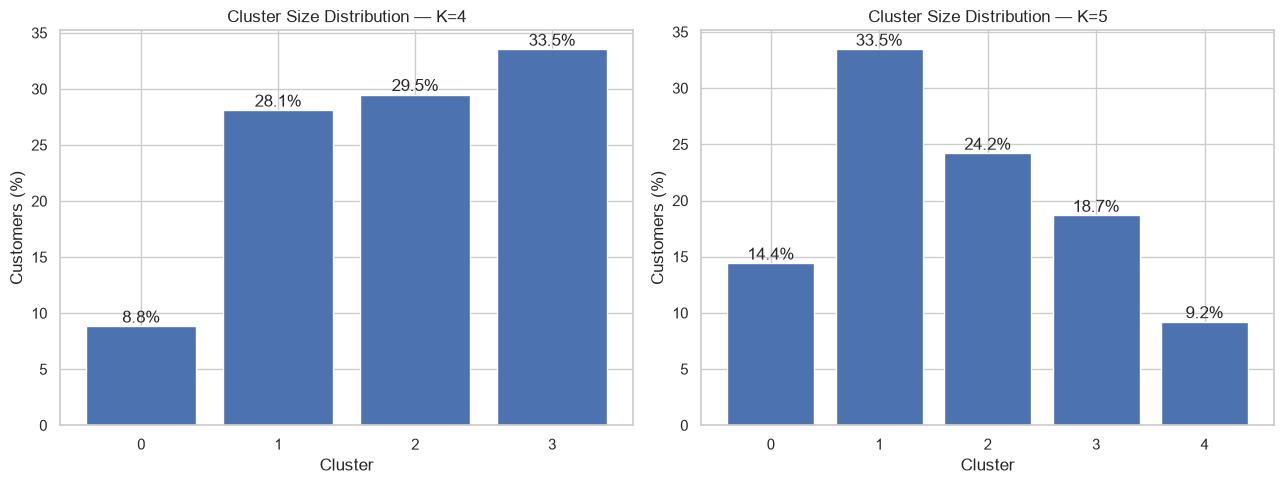

In [160]:
# Compare cluster sizes for K=4 and K=5

cluster_size_rows = []

for k in CANDIDATE_K:

    labels = candidate_labels[k]

    counts = (pd.Series(labels).value_counts().sort_index())

    for cluster, count in counts.items():

        cluster_size_rows.append({
            'K': k,
            'Cluster': cluster,
            'Customers': count,
            'Percentage': count / len(X) * 100
        })

cluster_sizes = pd.DataFrame(cluster_size_rows)

print(cluster_sizes.round(2).to_string(index=False))

# Visualise cluster proportions

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, k in zip(axes, CANDIDATE_K):

    data = cluster_sizes[
        cluster_sizes['K'] == k
    ]

    bars = ax.bar(
        data['Cluster'].astype(str),
        data['Percentage']
    )

    ax.set_title(
        f'Cluster Size Distribution — K={k}'
    )

    ax.set_xlabel('Cluster')
    ax.set_ylabel('Customers (%)')

    # Display percentages above each bar
    for bar, percentage in zip(
        bars,
        data['Percentage']
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{percentage:.1f}%',
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.show()

/Users/rmleader/practice-knn-kmeans/.venv/lib/python3.14/site-packages/pandas/core/apply.py:1183: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)


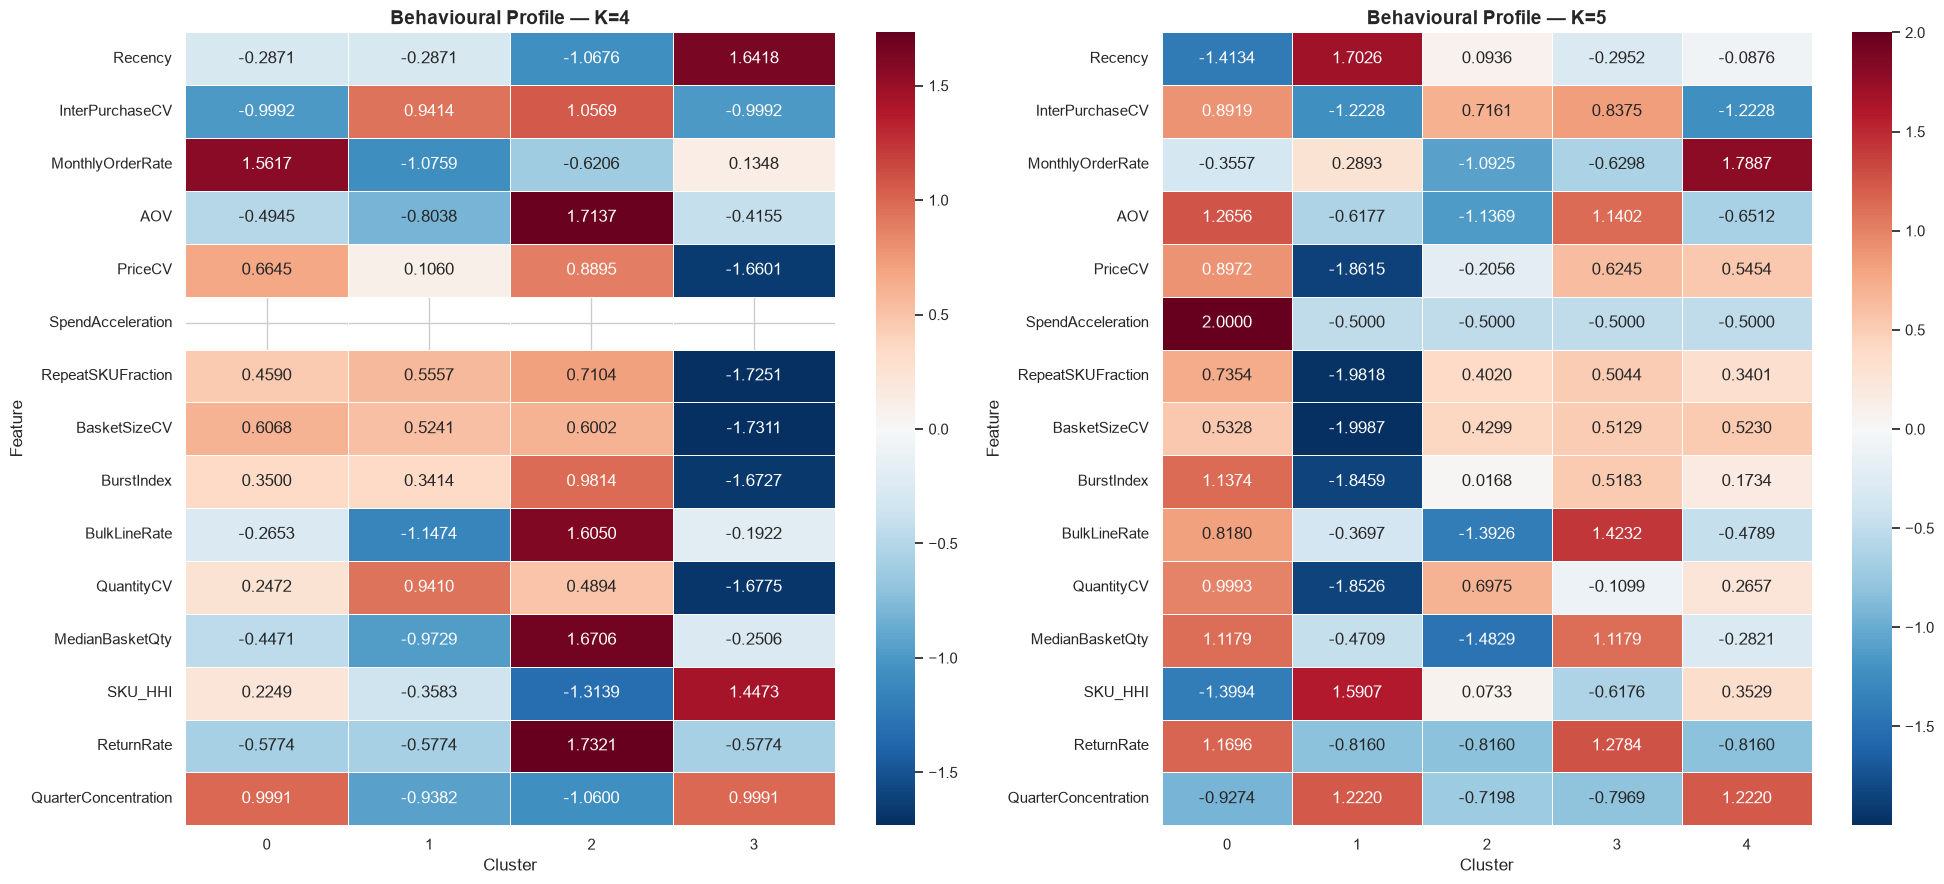

In [161]:
# Behavioural profile heatmaps

from scipy.stats import zscore

fig, axes = plt.subplots(1, 2,figsize=(20, 9)
)

for ax, k in zip(axes, CANDIDATE_K):

    profile = candidate_profiles[k]

    # Standardise each feature across clusters.
    # Positive values indicate relatively higher behaviour.
    # Negative values indicate relatively lower behaviour.
    profile_z = profile.apply(
        zscore,
        axis=0
    )
    
    sns.heatmap(
        profile_z.T,
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.4f',
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(f'Behavioural Profile — K={k}',fontsize=14, fontweight='bold')

    ax.set_xlabel('Cluster')
    ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()

In [162]:
print(candidate_profiles[4]['SpendAcceleration'])
print(candidate_profiles[4]['SpendAcceleration'].std())

Cluster
0   -0.030672
1   -0.030672
2   -0.030672
3   -0.030672
Name: SpendAcceleration, dtype: float64
0.0


In [163]:
# Automatic identification of distinctive features

for k in CANDIDATE_K:

    profile = candidate_profiles[k]

    # Standardise feature values across clusters
    profile_z = profile.apply(
        zscore,
        axis=0
    )

    print("\n" + "=" * 80)
    print(f"Distinctive features for K={k}")
    print("=" * 80)

    for cluster in profile_z.index:

        # Sort features by absolute deviation from the
        # overall cluster mean.
        distinctive = (
            profile_z.loc[cluster]
            .sort_values(
                key=lambda values: values.abs(),
                ascending=False
            )
            .head(5)
        )

        print(f"\nCluster {cluster}")

        for feature, value in distinctive.items():

            direction = (
                'High'
                if value > 0
                else 'Low'
            )

            print(
                f"  {feature:<25} "
                f"{direction:<5} "
                f"z={value:+.2f}"
            )


Distinctive features for K=4

Cluster 0
  MonthlyOrderRate          High  z=+1.56
  InterPurchaseCV           Low   z=-1.00
  QuarterConcentration      High  z=+1.00
  PriceCV                   High  z=+0.66
  BasketSizeCV              High  z=+0.61

Cluster 1
  BulkLineRate              Low   z=-1.15
  MonthlyOrderRate          Low   z=-1.08
  MedianBasketQty           Low   z=-0.97
  InterPurchaseCV           High  z=+0.94
  QuantityCV                High  z=+0.94

Cluster 2
  ReturnRate                High  z=+1.73
  AOV                       High  z=+1.71
  MedianBasketQty           High  z=+1.67
  BulkLineRate              High  z=+1.61
  SKU_HHI                   Low   z=-1.31

Cluster 3
  BasketSizeCV              Low   z=-1.73
  RepeatSKUFraction         Low   z=-1.73
  QuantityCV                Low   z=-1.68
  BurstIndex                Low   z=-1.67
  PriceCV                   Low   z=-1.66

Distinctive features for K=5

Cluster 0
  SpendAcceleration         High  z=+2.00
  R

/Users/rmleader/practice-knn-kmeans/.venv/lib/python3.14/site-packages/pandas/core/apply.py:1183: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)


PC1 explained variance: 41.21%
PC2 explained variance: 11.84%


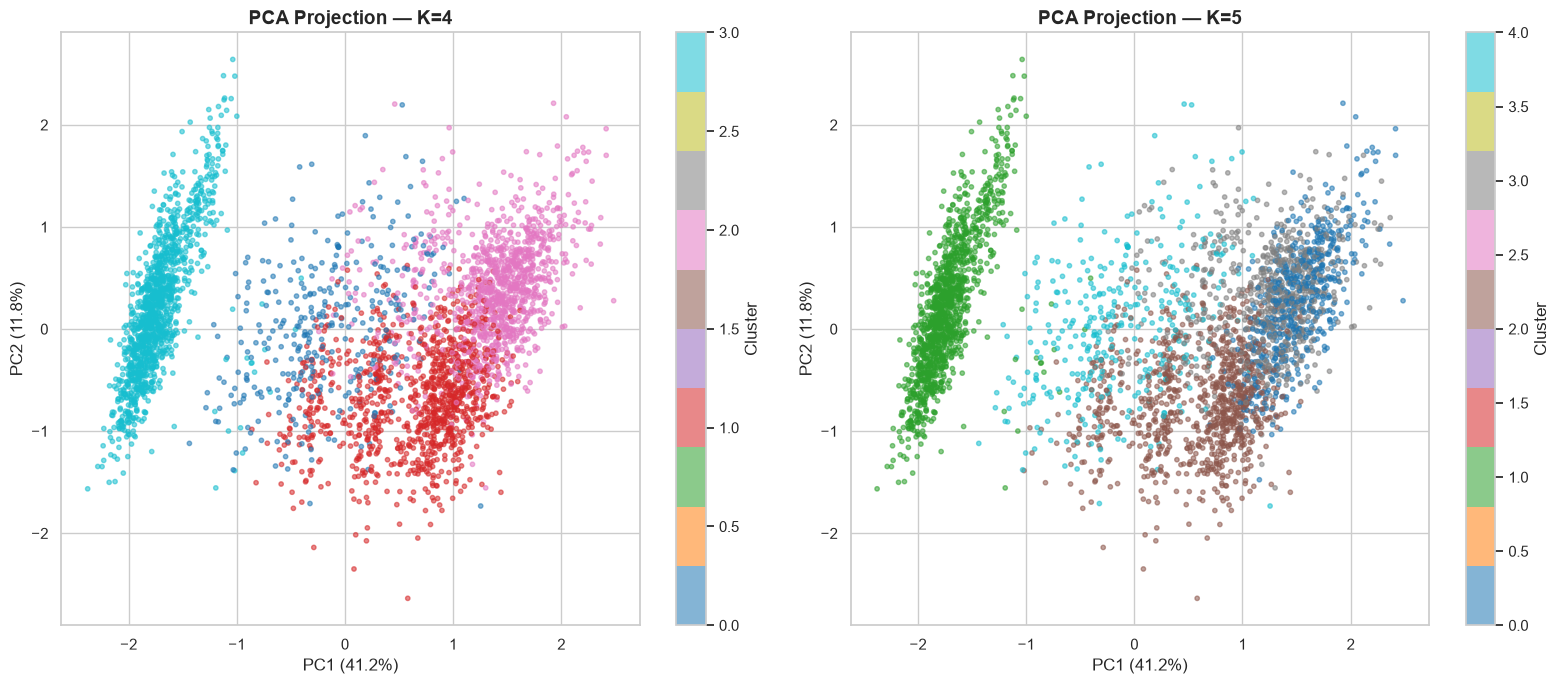

In [164]:
# PCA visualisation of K=4 and K=5

from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=BASE_SEED
)

X_pca = pca.fit_transform(X)

explained_1 = pca.explained_variance_ratio_[0]
explained_2 = pca.explained_variance_ratio_[1]

print(f"PC1 explained variance: {explained_1:.2%}")

print(f"PC2 explained variance: {explained_2:.2%}")

fig, axes = plt.subplots(1,2,figsize=(16, 7))

for ax, k in zip(axes, CANDIDATE_K):

    labels = candidate_labels[k]

    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        cmap='tab10',
        s=10,
        alpha=0.55
    )

    ax.set_title(
        f'PCA Projection — K={k}',
        fontsize=14,
        fontweight='bold'
    )

    ax.set_xlabel(f'PC1 ({explained_1:.1%})')

    ax.set_ylabel(f'PC2 ({explained_2:.1%})')

    plt.colorbar(
        scatter,
        ax=ax,
        label='Cluster'
    )

plt.tight_layout()
plt.show()

In [165]:
# Candidate comparison summary

candidate_summary = pd.DataFrame({

    'WCSS': [candidate_models[k].inertia_ for k in CANDIDATE_K],

    'Silhouette': [silhouette_score(X, candidate_labels[k]) for k in CANDIDATE_K],

    'DaviesBouldin': [davies_bouldin_score(X, candidate_labels[k]) for k in CANDIDATE_K],

    'CalinskiHarabasz': [calinski_harabasz_score(X, candidate_labels[k]) for k in CANDIDATE_K],

    'Silhouette_Std': [stability_summary.loc[k, 'Silhouette_Std']for k in CANDIDATE_K],

    'ARI_Mean': [ari_summary.loc[k, 'ARI_Mean']for k in CANDIDATE_K]
    
}, index=CANDIDATE_K)

candidate_summary.index.name = 'K'

print(
    candidate_summary
    .round(5)
    .to_string()
)

         WCSS  Silhouette  DaviesBouldin  CalinskiHarabasz  Silhouette_Std  ARI_Mean
K                                                                                   
4  8675.12425     0.25554        1.73214        1156.98954         0.00004   0.99916
5  7980.59232     0.25560        1.67362        1024.31289         0.00017   0.97700


## Final K Selection

K=4 was selected as the final clustering solution over K=5.

Although K=5 achieved a slightly lower Davies-Bouldin Index (1.674 vs. 1.732), the Silhouette scores of the two solutions were virtually identical (0.25560 vs. 0.25554). Therefore, the small improvement in internal clustering quality did not provide strong evidence for adding a fifth cluster.

The stability analysis further favoured K=4. The mean Adjusted Rand Index across multiple random initialisations was 0.999 for K=4, compared with 0.977 for K=5, indicating that the K=4 solution was more consistent across different initialisations.

The behavioural profile analysis also showed that K=4 produced four clearly distinguishable customer behaviours, while K=5 introduced an additional segmentation layer without a sufficiently distinct behavioural pattern. The PCA projection similarly showed considerable overlap among several K=5 clusters.

Therefore, K=4 provides the best overall balance between clustering quality, stability, interpretability, and model complexity.

FINAL K-MEANS MODEL | K=4
Number of customers : 3,742
Number of features  : 15
WCSS                : 8,675.1242
Silhouette Score    : 0.2555
Davies-Bouldin      : 1.7321
Calinski-Harabasz   : 1,156.9895

Cluster distribution:
         CustomerCount  Percentage
Cluster                           
0                  331        8.85
1                 1052       28.11
2                 1104       29.50
3                 1255       33.54

Final cluster median profile:
Cluster                   0      1      2      3
Recency              -0.059 -0.059 -0.210  0.313
InterPurchaseCV      -0.531  0.521  0.583 -0.531
MonthlyOrderRate      0.837 -0.457 -0.234  0.137
AOV                  -0.069 -0.106  0.202 -0.059
PriceCV               0.110  0.064  0.129 -0.081
SpendAcceleration    -0.031 -0.031 -0.031 -0.031
RepeatSKUFraction     0.435  0.490  0.579 -0.822
BasketSizeCV          0.515  0.464  0.511 -0.923
BurstIndex            0.129  0.127  0.321 -0.485
BulkLineRate         -0.023 -0.050  0.035 -

/Users/rmleader/practice-knn-kmeans/.venv/lib/python3.14/site-packages/pandas/core/apply.py:1183: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)


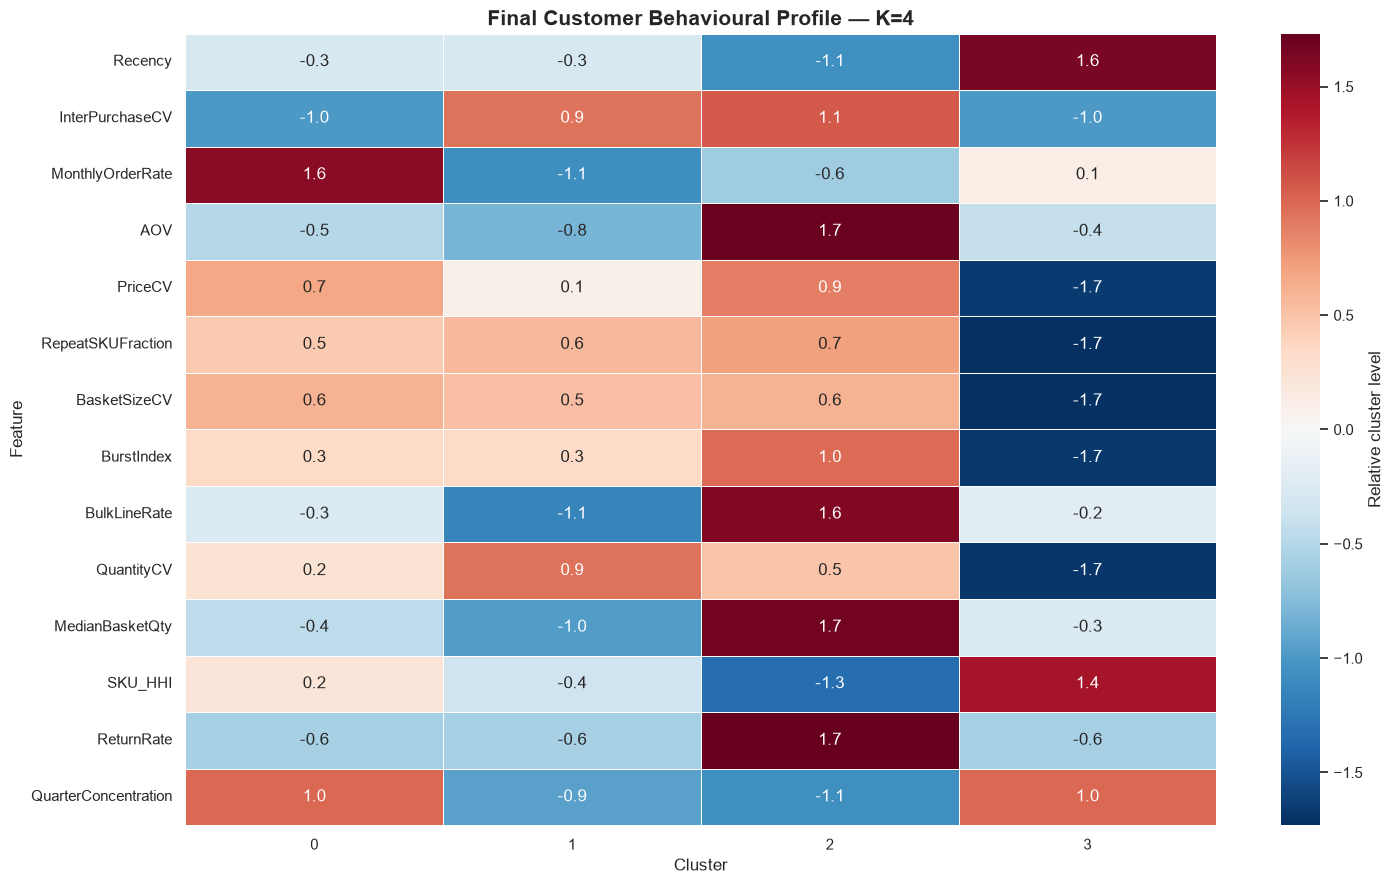


DISTINCTIVE FEATURES BY CLUSTER

Cluster 0
  MonthlyOrderRate          Higher   z=+1.56
  InterPurchaseCV           Lower    z=-1.00
  QuarterConcentration      Higher   z=+1.00
  PriceCV                   Higher   z=+0.66
  BasketSizeCV              Higher   z=+0.61
  ReturnRate                Lower    z=-0.58

Cluster 1
  BulkLineRate              Lower    z=-1.15
  MonthlyOrderRate          Lower    z=-1.08
  MedianBasketQty           Lower    z=-0.97
  InterPurchaseCV           Higher   z=+0.94
  QuantityCV                Higher   z=+0.94
  QuarterConcentration      Lower    z=-0.94

Cluster 2
  ReturnRate                Higher   z=+1.73
  AOV                       Higher   z=+1.71
  MedianBasketQty           Higher   z=+1.67
  BulkLineRate              Higher   z=+1.61
  SKU_HHI                   Lower    z=-1.31
  Recency                   Lower    z=-1.07

Cluster 3
  BasketSizeCV              Lower    z=-1.73
  RepeatSKUFraction         Lower    z=-1.73
  QuantityCV           

In [166]:
# ----------------------------------------------------
# Final Customer Segmentation Model
# ----------------------------------------------------
from sklearn.cluster import KMeans
from scipy.stats import zscore

FINAL_K = 4
RANDOM_STATE = 42

# Use the modelling matrix already prepared during K-selection.
X = df_modeling.copy()

# Train the final K-Means model using the selected number of clusters.
final_kmeans = KMeans(
    n_clusters=FINAL_K,
    init='k-means++',
    n_init=20,
    max_iter=300,
    random_state=RANDOM_STATE
)

final_labels = final_kmeans.fit_predict(X)

# Create a final customer-level dataset while preserving the original index.
df_final = df_modeling.copy()
df_final['Cluster'] = final_labels

# ------------------------------------------------------------
# Final model evaluation
# ------------------------------------------------------------

final_wcss = final_kmeans.inertia_
final_silhouette = silhouette_score(X, final_labels)
final_dbi = davies_bouldin_score(X, final_labels)
final_ch = calinski_harabasz_score(X, final_labels)

print("=" * 70)
print(f"FINAL K-MEANS MODEL | K={FINAL_K}")
print("=" * 70)
print(f"Number of customers : {len(df_final):,}")
print(f"Number of features  : {X.shape[1]}")
print(f"WCSS                : {final_wcss:,.4f}")
print(f"Silhouette Score    : {final_silhouette:.4f}")
print(f"Davies-Bouldin      : {final_dbi:.4f}")
print(f"Calinski-Harabasz   : {final_ch:,.4f}")

# ------------------------------------------------------------
# Cluster size and proportion
# ------------------------------------------------------------

cluster_size = (
    df_final['Cluster']
    .value_counts()
    .sort_index()
    .rename('CustomerCount')
    .to_frame()
)

cluster_size['Percentage'] = (
    cluster_size['CustomerCount']
    / len(df_final)
    * 100
)

print("\nCluster distribution:")
print(cluster_size.round(2).to_string())

# ------------------------------------------------------------
# Final behavioural profile
# ------------------------------------------------------------

# Median is used because behavioural customer features can be skewed
# by a small number of highly active or high-value customers.
final_profile = (
    df_final
    .groupby('Cluster')[X.columns]
    .median()
)

print("\nFinal cluster median profile:")
print(final_profile.round(3).T.to_string())

# ------------------------------------------------------------
# Standardised profile for visual comparison
# ------------------------------------------------------------

# Standardise each feature across clusters so that different
# feature scales can be compared visually.
final_profile_z = final_profile.apply(zscore, axis=0)

# Features with zero variance across clusters produce NaN z-scores.
# They do not help differentiate the final customer segments,
# so they are removed from the visualisation.
final_profile_z = final_profile_z.dropna(axis=1, how='all')

# ------------------------------------------------------------
# Behavioural profile heatmap
# ------------------------------------------------------------

plt.figure(figsize=(15, 9))

sns.heatmap(
    final_profile_z.T,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': 'Relative cluster level'}
)

plt.title(
    f'Final Customer Behavioural Profile — K={FINAL_K}',
    fontsize=15,
    fontweight='bold'
)
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Automatic identification of distinctive features
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DISTINCTIVE FEATURES BY CLUSTER")
print("=" * 70)

for cluster in final_profile_z.index:
    distinctive = (
        final_profile_z.loc[cluster]
        .sort_values(key=lambda values: values.abs(), ascending=False)
        .head(6)
    )

    print(f"\nCluster {cluster}")

    for feature, value in distinctive.items():
        direction = "Higher" if value > 0 else "Lower"
        print(f"  {feature:<25} {direction:<8} z={value:+.2f}")

# ------------------------------------------------------------
# Save final customer segmentation
# ------------------------------------------------------------

output_path = '../data/processed/final_customer_segments.csv'
df_final.to_csv(output_path, index=True)

print(f"\nFinal segmentation saved to: {output_path}")

## Customer Segment Identification & Business Personas (K=4)

This section summarizes the identification, behavioral profiling, and business rationale for each of the four customer clusters derived from the final K-Means model ($K=4$). Cluster names were assigned by analyzing each group's **distinctive features**—measured as standardized deviations ($z$-scores) from the overall customer population mean.

---

### 1. Cluster 0: **Frequent Seasonal Intensives** (8.85% of Customers, $N=331$)

* **Distinctive Features ($z$-scores):**
  * `MonthlyOrderRate`: **High** ($z = +1.56$) — High purchasing frequency
  * `InterPurchaseCV`: **Low** ($z = -1.00$) — Regular and predictable time gaps between orders
  * `QuarterConcentration`: **High** ($z = +1.00$) — Order activity is heavily concentrated in specific fiscal quarters
  * `PriceCV` & `BasketSizeCV`: **Moderate-High** ($z = +0.66$, $z = +0.61$)
* **Why This Identification? (Rationale):**
  * These customers exhibit a **high monthly order rate** coupled with **regular inter-purchase intervals**, indicating active, non-sporadic engagement.
  * However, their **quarterly concentration is exceptionally high**, meaning their buying activity spikes during specific seasons/quarters (e.g., holiday seasons, fiscal quarter ends).
* **Strategic Business Actions:**
  * Target with seasonal promotions and early-bird pre-order campaigns prior to their historical peak quarters.
  * Introduce cross-quarter loyalty incentives to smooth out seasonal demand dips.

---

### 2. Cluster 1: **Low-Volume Irregular Explorers** (28.11% of Customers, $N=1,052$)

* **Distinctive Features ($z$-scores):**
  * `BulkLineRate`: **Low** ($z = -1.15$) — Rarely purchase bulk items
  * `MonthlyOrderRate`: **Low** ($z = -1.08$) — Low purchasing frequency
  * `MedianBasketQty`: **Low** ($z = -0.97$) — Small quantities per order
  * `InterPurchaseCV`: **High** ($z = +0.94$) — Unpredictable and irregular purchase timing
  * `QuantityCV`: **High** ($z = +0.94$) — High variation in items per order
* **Why This Identification? (Rationale):**
  * This group represents **casual, low-engagement shoppers**. They order infrequently, buy small basket quantities, and do not follow a predictable purchase schedule.
  * They have high variance in order quantity (`QuantityCV`) and inter-purchase timing (`InterPurchaseCV`), characteristic of impulse or single-need buyers.
* **Strategic Business Actions:**
  * Implement automated re-engagement email flows and low-threshold discounts (e.g., "Free shipping on orders over $30").
  * Use recommendation engines to encourage repeat purchases and basket building.

---

### 3. Cluster 2: **High-Value Bulk Actives (High-Return B2B/Wholesale)** (29.50% of Customers, $N=1,104$)

* **Distinctive Features ($z$-scores):**
  * `ReturnRate`: **High** ($z = +1.73$) — Highest product return rate
  * `AOV` (Average Order Value): **High** ($z = +1.71$) — High monetary spend per order
  * `MedianBasketQty`: **High** ($z = +1.67$) — High volume/quantity per order
  * `BulkLineRate`: **High** ($z = +1.61$) — Frequently purchase wholesale/bulk lines
  * `SKU_HHI`: **Low** ($z = -1.31$) — Purchases spread across a wide range of SKUs
* **Why This Identification? (Rationale):**
  * This is the **highest-spending segment** characterized by large average order values, high item quantities, and heavy bulk buying. They browse and purchase across a wide variety of product categories (low HHI).
  * The notable trade-off is their **elevated return rate** ($z = +1.73$), typical of bulk purchasers, resellers, or corporate accounts ordering samples or over-ordering stock.
* **Strategic Business Actions:**
  * Assign dedicated account managers and offer volume-tier pricing.
  * Investigate root causes for high return rates (e.g., product sizing/specifications) and offer tailored return policies or pre-purchase consultations to mitigate return costs.

---

### 4. Cluster 3: **Steady Routine Buyers (Occasional Loyalists)** (33.54% of Customers, $N=1,255$)

* **Distinctive Features ($z$-scores):**
  * `BasketSizeCV`: **Low** ($z = -1.73$) — Remarkably stable basket sizes across orders
  * `RepeatSKUFraction`: **Low** ($z = -1.73$) — Buys varied products rather than repeating identical SKUs
  * `QuantityCV`: **Low** ($z = -1.68$) — Highly consistent item counts per order
  * `BurstIndex`: **Low** ($z = -1.67$) — Steady, non-bursty purchase rhythm
  * `PriceCV`: **Low** ($z = -1.66$) — Orders stick to consistent price points
* **Why This Identification? (Rationale):**
  * Representing the **largest segment (33.5%)**, these shoppers exhibit **extremely low variance** across all order metrics (basket size, item quantity, price tier, purchase rhythm).
  * They buy on a steady, predictable schedule without impulse spikes or sudden changes in order composition, making them reliable, low-maintenance customers.
* **Strategic Business Actions:**
  * Focus on long-term retention and subscription/auto-replenishment programs.
  * Upsell higher-margin products within their preferred price tiers to gradually increase lifetime value.

---

### 📌 Summary Comparison Matrix

| Cluster ID | Segment Name | Size (%) | Key High Features | Key Low Features | Primary Persona |
| :---: | :--- | :---: | :--- | :--- | :--- |
| **0** | **Frequent Seasonal Intensives** | 8.85% | `MonthlyOrderRate`, `QuarterConcentration` | `InterPurchaseCV` | High-frequency seasonal shoppers |
| **1** | **Low-Volume Irregular Explorers** | 28.11% | `InterPurchaseCV`, `QuantityCV` | `BulkLineRate`, `MonthlyOrderRate`, `MedianBasketQty` | Sporadic, low-spend casual buyers |
| **2** | **High-Value Bulk Actives** | 29.50% | `ReturnRate`, `AOV`, `MedianBasketQty`, `BulkLineRate` | `SKU_HHI` | Large-volume VIP/B2B buyers with high returns |
| **3** | **Steady Routine Buyers** | 33.54% | Moderate baseline metrics | `BasketSizeCV`, `RepeatSKUFraction`, `QuantityCV`, `BurstIndex`, `PriceCV` | Predictable, low-variance routine customers |
